<div align="center">

# IMAM ABDULRAHMAN BIN FAISAL UNIVERSITY
### College of Computer Science and Information Technology
### Department of Computer Engineering

---

## ARTI 403 – Image Processing
## Student Procedural Manual — **Lab 1**
### Basics of Programming with Python
**Academic Year 2026 – 2027**

</div>

---

| | |
|---|---|
| **Name** | **Nawaf Mohammed Alghamdi** |
| **ID** | **2240007352** |
| **Course** | ARTI 403 – Image Processing |
| **Session** | 1 — Basics of programming with Python (100 minutes) |

## 1 — Session Outcome

**Outcome #1:** Explain how digital images are represented and manipulated in a computer.

## 2 — Tools / Software

* Python 3
* Anaconda
* IDE for Python: Jupyter Notebook, Spyder

## 3 — Sample Images Used

The lab manual refers to `images/cameraman.tif` and `images/lena_gray_256.tif`.
The images used in this submission are taken from the scikit-image
**General-purpose images** gallery:

<https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html>

These images ship inside the `scikit-image` package, so **this notebook is
fully self-contained**: the setup cell below writes every gallery image into a
local `images/` folder itself. No other file and no internet connection are
needed — just open the notebook and choose *Run All*.

> **Note on `lena_gray_256.tif`:** the *Lena* photograph was removed from
> scikit-image (and from most modern image-processing libraries) for licensing
> and ethical reasons. This lab substitutes `astronaut_gray_256.tif` — the
> `astronaut` gallery image converted to grayscale and resized to 256 × 256,
> so it matches the dimensions and the single-channel format the manual expects.

---

# 4 — Procedural Steps

## Step #1 — Install Anaconda

Anaconda was downloaded and installed from <https://www.anaconda.com/>.
After installation, Anaconda Navigator provides **Jupyter Notebook** and
**Spyder**, which are the two target IDEs for this course.

## Step #2 — Start Jupyter or Spyder

Both IDEs can be launched from Anaconda Navigator, or directly from the Windows
Start menu without opening Navigator first (this is the faster route).

From a terminal / Anaconda Prompt they can also be started with:

```bash
jupyter notebook
spyder
```

## Step #3 — Install the required libraries / packages

The libraries needed for this course are **SciPy, OpenCV, scikit-image,
Pillow** and **Matplotlib**.

## Step #4 — Install NumPy

NumPy is published on PyPI at <https://pypi.org/project/numpy/> and is
installed the same way as the packages above.

The install commands are listed below. They are commented out because these
packages are already present in the Anaconda environment used for this lab —
remove the `#` to run them on a fresh machine.

In [1]:
# !pip install numpy
# !pip install scipy
# !pip install opencv-python
# !pip install scikit-image
# !pip install pillow
# !pip install matplotlib

# !conda install -y numpy scipy scikit-image pillow matplotlib
# !conda install -y -c conda-forge opencv

### Verifying the installation

Before writing any image-processing code, it is worth confirming that every
package imports correctly and checking which version is installed. A version
mismatch is the most common cause of an example that "should work" but does not.

In [2]:
import sys
import platform

import numpy as np
import scipy
import cv2
import skimage
import PIL
import matplotlib

print("Python  :", sys.version.split()[0], "on", platform.system())
print()
print(f"{'package':<15}version")
print("-" * 30)
for name, module in [
    ("numpy", np),
    ("scipy", scipy),
    ("opencv-python", cv2),
    ("scikit-image", skimage),
    ("pillow", PIL),
    ("matplotlib", matplotlib),
]:
    print(f"{name:<15}{module.__version__}")

Python  : 3.12.3 on Linux

package        version
------------------------------
numpy          2.4.4
scipy          1.17.1
opencv-python  4.13.0
scikit-image   0.26.0
pillow         12.1.1
matplotlib     3.10.8


In [3]:
import os

import imageio.v3 as iio
import skimage.data
from skimage.color import rgb2gray, rgba2rgb
from skimage.transform import resize
from skimage.util import img_as_ubyte

os.makedirs("images", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

GALLERY = ['astronaut', 'binary_blobs', 'camera', 'checkerboard', 'clock',
           'coffee', 'coins', 'colorwheel', 'horse', 'logo', 'page', 'text']

def to_uint8(image):
    if image.dtype == bool:
        return image.astype(np.uint8) * 255
    return img_as_ubyte(image)

for name in GALLERY:
    iio.imwrite(f"images/{name}.png", to_uint8(getattr(skimage.data, name)()))

iio.imwrite("images/cameraman.tif", to_uint8(skimage.data.camera()))

iio.imwrite(
    "images/astronaut_gray_256.tif",
    img_as_ubyte(resize(rgb2gray(skimage.data.astronaut()), (256, 256),
                        anti_aliasing=True)),
)

iio.imwrite("images/logo_rgb.png", img_as_ubyte(rgba2rgb(skimage.data.logo())))

print(f"{'file':<26}{'size':>10}")
print("-" * 36)
for f in sorted(os.listdir("images")):
    print(f"{f:<26}{os.path.getsize('images/' + f) / 1024:>8.1f} KB")

file                            size
------------------------------------
astronaut.png                414.6 KB
astronaut_gray_256.tif        64.2 KB
binary_blobs.png               7.1 KB
camera.png                   139.0 KB
cameraman.tif                256.2 KB
checkerboard.png               0.4 KB
clock.png                     43.4 KB
coffee.png                   438.7 KB
coins.png                     74.0 KB
colorwheel.png                81.2 KB
horse.png                      2.4 KB
logo.png                     175.5 KB
logo_rgb.png                 163.3 KB
page.png                      41.6 KB
text.png                      41.7 KB


---

# Task #1 — Exercise with Spyder: Python practice

This task works through the two cheat sheets from the Resources section —
**Python Basics** and **NumPy** — because every later task manipulates images
as NumPy arrays.

## 1.1 Variables, data types and operators

In [4]:
student_name = "Nawaf Mohammed Alghamdi"
student_id   = 2240007352
gpa          = 4.35
is_enrolled  = True

for value in (student_name, student_id, gpa, is_enrolled):
    print(f"{str(value):<25} -> {type(value).__name__}")

Nawaf Mohammed Alghamdi   -> str
2240007352                -> int
4.35                      -> float
True                      -> bool


In [5]:
a, b = 17, 5

print("a + b  =", a + b)
print("a - b  =", a - b)
print("a * b  =", a * b)
print("a / b  =", a / b)
print("a // b =", a // b)
print("a mod b =", a % b)
print("a ** 2 =", a ** 2)

a + b  = 22
a - b  = 12
a * b  = 85
a / b  = 3.4
a // b = 3
a mod b = 2
a ** 2 = 289


In [6]:
course = "ARTI 403 - Image Processing"

print("upper      :", course.upper())
print("split      :", course.split(" - "))
print("slice [0:8]:", course[0:8])
print("replace    :", course.replace("403", "403 Lab 1"))
print("f-string   :", f"{student_name} ({student_id}) is taking {course}.")

upper      : ARTI 403 - IMAGE PROCESSING
split      : ['ARTI 403', 'Image Processing']
slice [0:8]: ARTI 403
replace    : ARTI 403 Lab 1 - Image Processing
f-string   : Nawaf Mohammed Alghamdi (2240007352) is taking ARTI 403 - Image Processing.


## 1.2 Collections: list, tuple, dictionary and set

In [7]:
pixels = [12, 240, 3, 128, 77]
print("original      :", pixels)

pixels.append(200)
pixels.sort()
print("appended+sort :", pixels)
print("first / last  :", pixels[0], "/", pixels[-1])
print("slice [1:4]   :", pixels[1:4])
print("length        :", len(pixels))

shape = (512, 512, 3)
print("\ntuple shape   :", shape, "-> rows =", shape[0], ", cols =", shape[1])

image_info = {"name": "cameraman", "width": 512, "height": 512, "channels": 1}
print("\ndictionary    :", image_info)
print("keys          :", list(image_info.keys()))
for key, value in image_info.items():
    print(f"  {key:<10}= {value}")

gray_levels = {0, 128, 255, 128, 0}
print("\nset (unique)  :", gray_levels)

original      : [12, 240, 3, 128, 77]
appended+sort : [3, 12, 77, 128, 200, 240]
first / last  : 3 / 240
slice [1:4]   : [12, 77, 128]
length        : 6

tuple shape   : (512, 512, 3) -> rows = 512 , cols = 512

dictionary    : {'name': 'cameraman', 'width': 512, 'height': 512, 'channels': 1}
keys          : ['name', 'width', 'height', 'channels']
  name      = cameraman
  width     = 512
  height    = 512
  channels  = 1

set (unique)  : {0, 128, 255}


## 1.3 Control flow: conditions and loops

In [8]:
def describe_pixel(value):
    '''Classify an 8-bit gray level.'''
    if value < 85:
        return "dark"
    elif value < 170:
        return "mid-gray"
    else:
        return "bright"

for value in [10, 128, 250]:
    print(f"pixel {value:>3} -> {describe_pixel(value)}")

print("\nsquares:", [n ** 2 for n in range(1, 6)])

level, count = 1, 0
while level < 256:
    level *= 2
    count += 1
print(f"\n256 gray levels need {count} bits per pixel.")

pixel  10 -> dark
pixel 128 -> mid-gray
pixel 250 -> bright

squares: [1, 4, 9, 16, 25]

256 gray levels need 8 bits per pixel.


## 1.4 Functions

A function that will actually be reused later in the notebook: a helper that
prints the essential properties of an image array.

In [9]:
def image_summary(array, label="image"):
    '''Print the shape, dtype, size and intensity range of an image array.'''
    channels = 1 if array.ndim == 2 else array.shape[2]
    print(f"--- {label} ---")
    print(f"  shape       : {array.shape}")
    print(f"  dtype       : {array.dtype}")
    print(f"  dimensions  : {array.ndim}  ({channels} channel(s))")
    print(f"  total pixels: {array.size:,}")
    print(f"  min / max   : {array.min()} / {array.max()}")
    print(f"  mean        : {array.mean():.2f}")
    return array.shape

_ = image_summary(np.arange(24).reshape(4, 6), label="demo array")

--- demo array ---
  shape       : (4, 6)
  dtype       : int64
  dimensions  : 2  (1 channel(s))
  total pixels: 24
  min / max   : 0 / 23
  mean        : 11.50


## 1.5 NumPy basics

NumPy is the foundation of everything that follows: **a digital image is simply
a NumPy array of numbers**. A grayscale image is a 2-D array of shape
`(height, width)`; a colour image is a 3-D array of shape
`(height, width, 3)`.

In [10]:
print("from list  :", np.array([1, 2, 3, 4]))
print("zeros      :", np.zeros(5, dtype=np.uint8))
print("ones       :", np.ones(5, dtype=np.uint8))
print("arange     :", np.arange(0, 10, 2))
print("linspace   :", np.linspace(0, 255, 5, dtype=np.uint8))
print("full       :", np.full(4, 128, dtype=np.uint8))

from list  : [1 2 3 4]
zeros      : [0 0 0 0 0]
ones       : [1 1 1 1 1]
arange     : [0 2 4 6 8]
linspace   : [  0  63 127 191 255]
full       : [128 128 128 128]


In [11]:
matrix = np.arange(12).reshape(3, 4)
print("matrix:\n", matrix)
print("\nshape      :", matrix.shape)
print("ndim       :", matrix.ndim)
print("dtype      :", matrix.dtype)
print("size       :", matrix.size)

print("\nelement [1, 2]     :", matrix[1, 2])
print("row 0              :", matrix[0])
print("column 3           :", matrix[:, 3])
print("sub-block [0:2,1:3]:\n", matrix[0:2, 1:3])
print("last row           :", matrix[-1])

matrix:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

shape      : (3, 4)
ndim       : 2
dtype      : int64
size       : 12

element [1, 2]     : 6
row 0              : [0 1 2 3]
column 3           : [ 3  7 11]
sub-block [0:2,1:3]:
 [[1 2]
 [5 6]]
last row           : [ 8  9 10 11]


In [12]:
x = np.array([[1, 2], [3, 4]])
y = np.array([[10, 20], [30, 40]])

print("x + y  :\n", x + y)
print("\nx * 3  :\n", x * 3)
print("\nx * y (element-wise):\n", x * y)
print("\nx @ y (matrix product):\n", x @ y)

print("\nsum / mean / std :", y.sum(), y.mean(), f"{y.std():.2f}")
print("min / max        :", y.min(), y.max())
print("column sums      :", y.sum(axis=0))
print("row sums         :", y.sum(axis=1))
print("transpose        :\n", y.T)

x + y  :
 [[11 22]
 [33 44]]

x * 3  :
 [[ 3  6]
 [ 9 12]]

x * y (element-wise):
 [[ 10  40]
 [ 90 160]]

x @ y (matrix product):
 [[ 70 100]
 [150 220]]

sum / mean / std : 100 25.0 11.18
min / max        : 10 40
column sums      : [40 60]
row sums         : [30 70]
transpose        :
 [[10 30]
 [20 40]]


In [13]:
values = np.array([12, 240, 3, 128, 77, 200])

mask = values > 100
print("values      :", values)
print("mask (>100) :", mask)
print("selected    :", values[mask])
print("count       :", mask.sum())

copy = values.copy()
copy[mask] = 255
print("thresholded :", copy)

values      : [ 12 240   3 128  77 200]
mask (>100) : [False  True False  True False  True]
selected    : [240 128 200]
count       : 3
thresholded : [ 12 255   3 255  77 255]


---

# Task #2 — Loading and Visualizing Images

## 2.1 Loading / reading an image using OpenCV

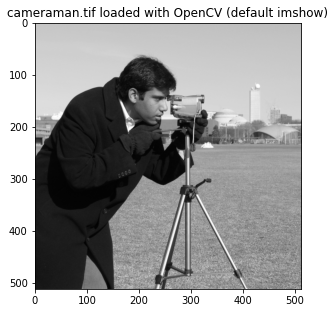

In [14]:
import cv2

img = cv2.imread('images/cameraman.tif')   # load the image data into a NumPy array

import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['figure.dpi'] = 72

plt.imshow(img)
plt.title("cameraman.tif loaded with OpenCV (default imshow)")
plt.show()

### Two important observations about `cv2.imread`

1. **OpenCV uses BGR order, Matplotlib expects RGB.** For a colour image this
   swaps the red and blue channels and the picture looks wrong. `cameraman.tif`
   is gray, so all three channels are identical and the error is invisible here
   — but it matters as soon as a colour image is loaded.
2. **`cv2.imread` returns 3 channels by default**, even for a grayscale file.
   Passing `cv2.IMREAD_GRAYSCALE` keeps it as a true 2-D array.

Both issues are demonstrated below.

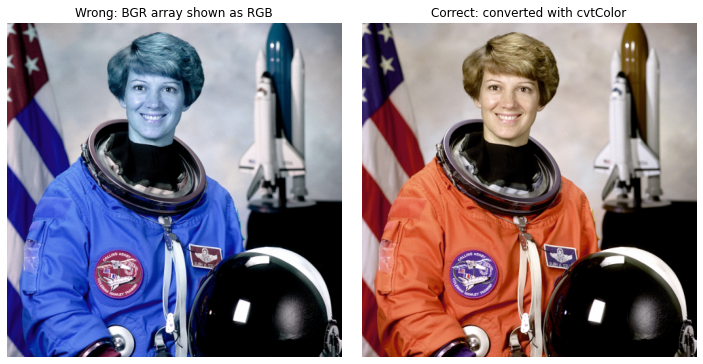

In [15]:
color_bgr = cv2.imread('images/astronaut.png')
color_rgb = cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(color_bgr)
axes[0].set_title("Wrong: BGR array shown as RGB")
axes[1].imshow(color_rgb)
axes[1].set_title("Correct: converted with cvtColor")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

default read     : (512, 512, 3) <- 3 identical channels
IMREAD_GRAYSCALE : (512, 512) <- 2-D array


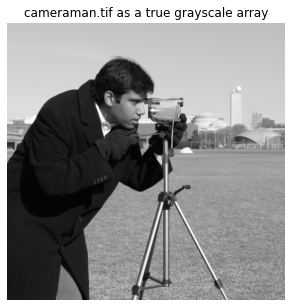

In [16]:
img_gray = cv2.imread('images/cameraman.tif', cv2.IMREAD_GRAYSCALE)

print("default read     :", img.shape,      "<- 3 identical channels")
print("IMREAD_GRAYSCALE :", img_gray.shape, "<- 2-D array")

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title("cameraman.tif as a true grayscale array")
plt.axis("off")
plt.show()

## 2.2 Loading / reading an image using PIL (Pillow)

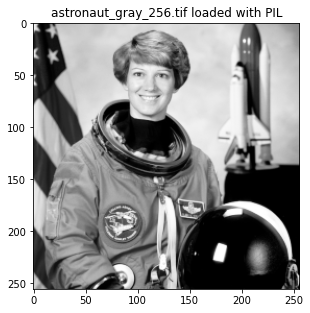

In [17]:
from PIL import Image

img2 = Image.open('images/astronaut_gray_256.tif')   # load image into a PIL Image object

import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.imshow(img2, cmap=cm.Greys_r)
plt.title("astronaut_gray_256.tif loaded with PIL")
plt.show()

In [18]:
print("type   :", type(img2))
print("format :", img2.format)
print("mode   :", img2.mode, " (L = 8-bit grayscale, RGB = 3x8-bit colour)")
print("size   :", img2.size, " (PIL reports width x height)")

type   : <class 'PIL.TiffImagePlugin.TiffImageFile'>
format : TIFF
mode   : L  (L = 8-bit grayscale, RGB = 3x8-bit colour)
size   : (256, 256)  (PIL reports width x height)


Note the difference in convention:

| Library | Object type | Size convention |
|---|---|---|
| OpenCV | `numpy.ndarray` | `array.shape` → `(height, width, channels)` |
| PIL | `PIL.Image.Image` | `img.size` → `(width, height)` |

Mixing the two up is one of the most common bugs in a first image-processing lab.

## 2.3 Comparing both loaders side by side

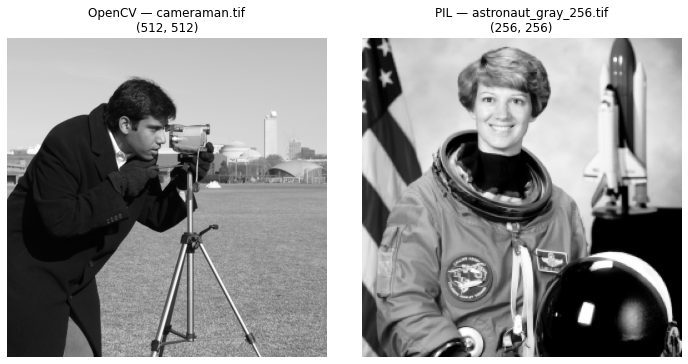

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title(f"OpenCV — cameraman.tif\n{img_gray.shape}")

axes[1].imshow(img2, cmap=cm.Greys_r)
axes[1].set_title(f"PIL — astronaut_gray_256.tif\n{img2.size[::-1]}")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task2_opencv_vs_pil.png", dpi=100, bbox_inches="tight")
plt.show()

---

# Task #3 — Image Storing

## 3.1 Saving an image to disk using OpenCV

In [20]:
cv2.imwrite('outputs/new_image.jpg', img)

print("saved  :", os.path.exists('outputs/new_image.jpg'))
print("bytes  :", os.path.getsize('outputs/new_image.jpg'))

saved  : True
bytes  : 86612


`cv2.imwrite` picks the file format from the **extension of the filename**, not
from the array. Writing `.jpg` applies lossy JPEG compression; writing `.png`
or `.tif` keeps every pixel exactly.

## 3.2 Saving an image to disk using PIL

In [21]:
img2.save('outputs/new_image2.jpg')

print("saved  :", os.path.exists('outputs/new_image2.jpg'))
print("bytes  :", os.path.getsize('outputs/new_image2.jpg'))

saved  : True
bytes  : 11981


## 3.3 Lossy vs lossless: what compression actually costs

A short experiment to make the difference concrete — the same array is written
as PNG (lossless) and as JPEG at two quality settings, then read back and
compared against the original pixel by pixel.

In [22]:
cv2.imwrite('outputs/cameraman_lossless.png', img_gray)
cv2.imwrite('outputs/cameraman_q90.jpg', img_gray, [cv2.IMWRITE_JPEG_QUALITY, 90])
cv2.imwrite('outputs/cameraman_q10.jpg', img_gray, [cv2.IMWRITE_JPEG_QUALITY, 10])

print(f"{'file':<32}{'KB':>8}{'max pixel error':>18}")
print("-" * 58)
for filename in ['cameraman_lossless.png', 'cameraman_q90.jpg', 'cameraman_q10.jpg']:
    path = f'outputs/{filename}'
    reloaded = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    error = np.abs(reloaded.astype(int) - img_gray.astype(int)).max()
    print(f"{filename:<32}{os.path.getsize(path)/1024:>8.1f}{error:>18}")

file                                  KB   max pixel error
----------------------------------------------------------
cameraman_lossless.png             144.9                 0
cameraman_q90.jpg                   58.0                18
cameraman_q10.jpg                    7.3               107


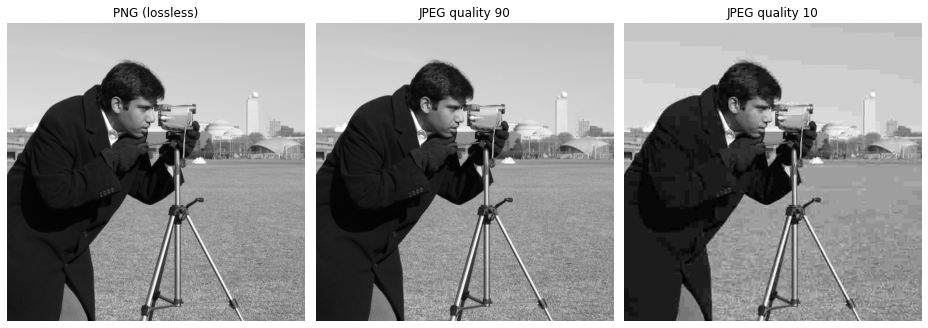

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, filename, label in zip(
    axes,
    ['cameraman_lossless.png', 'cameraman_q90.jpg', 'cameraman_q10.jpg'],
    ['PNG (lossless)', 'JPEG quality 90', 'JPEG quality 10'],
):
    ax.imshow(cv2.imread(f'outputs/{filename}', cv2.IMREAD_GRAYSCALE), cmap='gray')
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task3_compression.png", dpi=100, bbox_inches="tight")
plt.show()

At quality 10 the blocky 8 × 8 JPEG artefacts are clearly visible, and the
worst-case pixel error is large — while the PNG round-trips with an error of
exactly 0. This is why lossless formats such as PNG or TIFF are used for
image-processing work, and JPEG is reserved for final display.

---

# Task #4 — Display Image as an Array

## 4.1 The OpenCV image (already a NumPy array)

In [24]:
print(img.shape)   # Note: img loaded using OpenCV is a numpy array
print(img)

(512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]


The output above is truncated by NumPy — it prints the corners and replaces the
middle with `...`. The shape `(512, 512, 3)` means 512 rows, 512 columns and
3 channels, so this array holds 512 × 512 × 3 = 786,432 numbers.

## 4.2 Converting the PIL image to a NumPy array

In [25]:
import numpy as np

# Convert the image to a NumPy array
img_array = np.array(img2)

# Print the array
print(img_array.shape)
print(img_array)

(256, 256)
[[142  93 117 ... 120 120 117]
 [197 178 184 ... 118 119 118]
 [225 217 211 ... 119 119 119]
 ...
 [172 174 168 ...  62  27   0]
 [173 170 159 ...  48   3   0]
 [171 164 147 ...  77  22   0]]


## 4.3 Reading the numbers

Printing a whole array is not very informative. Looking at a small patch — and
at the same patch rendered as pixels — makes the connection between *numbers*
and *picture* explicit.

In [26]:
_ = image_summary(img_gray,   label="cameraman.tif (OpenCV, grayscale)")
print()
_ = image_summary(img_array,  label="astronaut_gray_256.tif (PIL -> NumPy)")
print()
_ = image_summary(color_rgb,  label="astronaut.png (OpenCV, RGB)")

--- cameraman.tif (OpenCV, grayscale) ---
  shape       : (512, 512)
  dtype       : uint8
  dimensions  : 2  (1 channel(s))
  total pixels: 262,144
  min / max   : 0 / 255
  mean        : 129.06

--- astronaut_gray_256.tif (PIL -> NumPy) ---
  shape       : (256, 256)
  dtype       : uint8
  dimensions  : 2  (1 channel(s))
  total pixels: 65,536
  min / max   : 0 / 254
  mean        : 112.70

--- astronaut.png (OpenCV, RGB) ---
  shape       : (512, 512, 3)
  dtype       : uint8
  dimensions  : 3  (3 channel(s))
  total pixels: 786,432
  min / max   : 0 / 255
  mean        : 114.60


Raw pixel values of img_gray[176:184, 48:56]:

[[254 253 252 254 253 157  45  33]
 [253 253 253 254 229  62  38  34]
 [241 245 249 252 150  45  36  32]
 [250 244 231 214  55  39  38  33]
 [255 250 234 120  46  33  34  33]
 [255 254 206  46  38  30  34  33]
 [252 244 101  45  28  30  33  31]
 [248 170  42  34  22  25  29  32]]


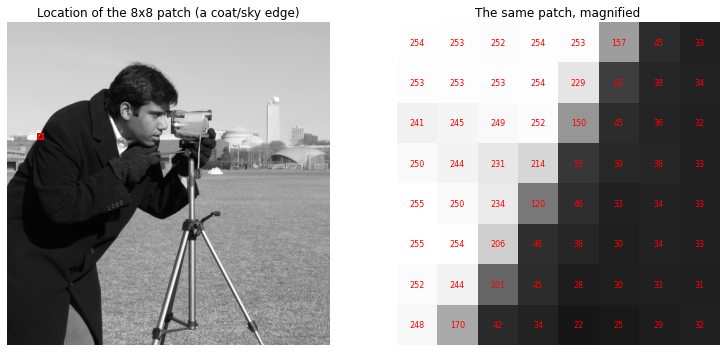

In [27]:
patch = img_gray[176:184, 48:56]

print("Raw pixel values of img_gray[176:184, 48:56]:\n")
print(patch)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(img_gray, cmap='gray')
axes[0].add_patch(plt.Rectangle((48, 176), 8, 8, edgecolor='red',
                                facecolor='none', linewidth=2))
axes[0].set_title("Location of the 8x8 patch (a coat/sky edge)")
axes[0].axis("off")

axes[1].imshow(patch, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("The same patch, magnified")
for (row, col), value in np.ndenumerate(patch):
    axes[1].text(col, row, str(value), ha='center', va='center',
                 color='red', fontsize=8)
axes[1].axis("off")

plt.tight_layout()
plt.savefig("outputs/task4_pixel_patch.png", dpi=100, bbox_inches="tight")
plt.show()

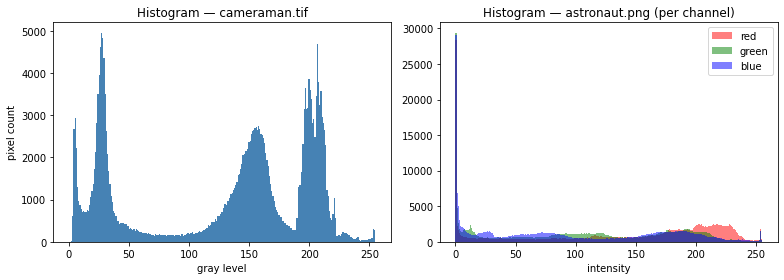

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(img_gray.ravel(), bins=256, range=(0, 255), color='steelblue')
axes[0].set_title("Histogram — cameraman.tif")
axes[0].set_xlabel("gray level"); axes[0].set_ylabel("pixel count")

for channel, colour in zip(range(3), ['red', 'green', 'blue']):
    axes[1].hist(color_rgb[:, :, channel].ravel(), bins=256, range=(0, 255),
                 color=colour, alpha=0.5, label=colour)
axes[1].set_title("Histogram — astronaut.png (per channel)")
axes[1].set_xlabel("intensity"); axes[1].legend()

plt.tight_layout()
plt.savefig("outputs/task4_histograms.png", dpi=100, bbox_inches="tight")
plt.show()

---

# 5 — Assessment: NumPy Operations on the Image Array

> *"The student will be asked to perform different operations on the array
> using the NumPy library."* — Section 4 of the lab manual

Every operation below is plain NumPy: no image-processing function is called.
This is the point of the lab — once the image is an array, array arithmetic
**is** image processing.

## 5.1 Slicing — cropping

original: (512, 512) ->  crop: (250, 250)


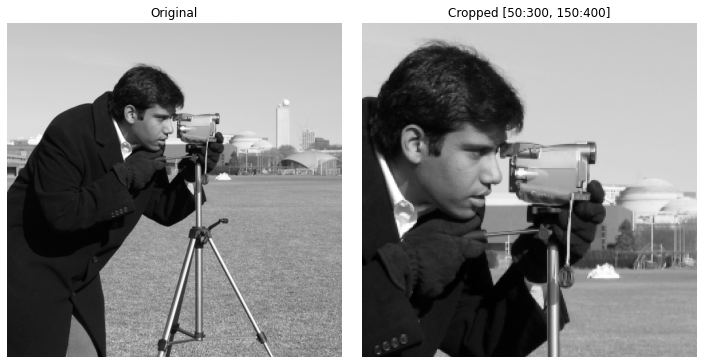

In [29]:
crop = img_gray[50:300, 150:400]

print("original:", img_gray.shape, "->  crop:", crop.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(crop,     cmap='gray'); axes[1].set_title("Cropped [50:300, 150:400]")
for ax in axes:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 5.2 Negative indexing — flipping and rotating

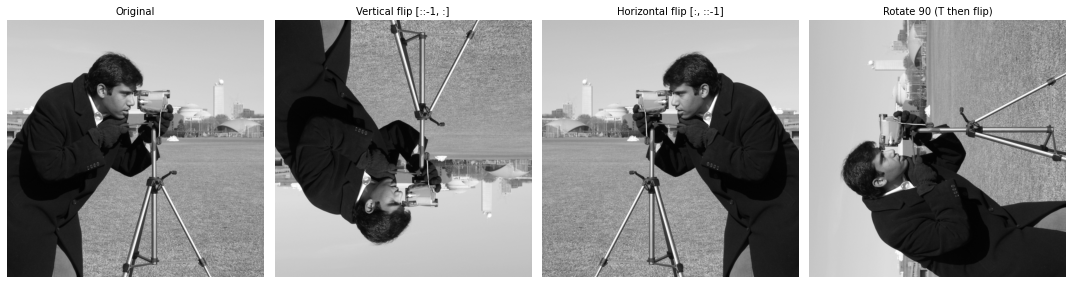

In [30]:
flip_v   = img_gray[::-1, :]
flip_h   = img_gray[:, ::-1]
rotate90 = img_gray.T[::-1, :]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, image, title in zip(
    axes,
    [img_gray, flip_v, flip_h, rotate90],
    ["Original", "Vertical flip [::-1, :]", "Horizontal flip [:, ::-1]", "Rotate 90 (T then flip)"],
):
    ax.imshow(image, cmap='gray'); ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task5_flips.png", dpi=100, bbox_inches="tight")
plt.show()

## 5.3 Arithmetic — brightness, contrast and the negative

Care is needed with `uint8`: 200 + 100 wraps around to 44 instead of saturating
at 255. Casting to `int` first, then clipping, avoids the wrap-around.

uint8 overflow demo: 44   <- wrapped around!


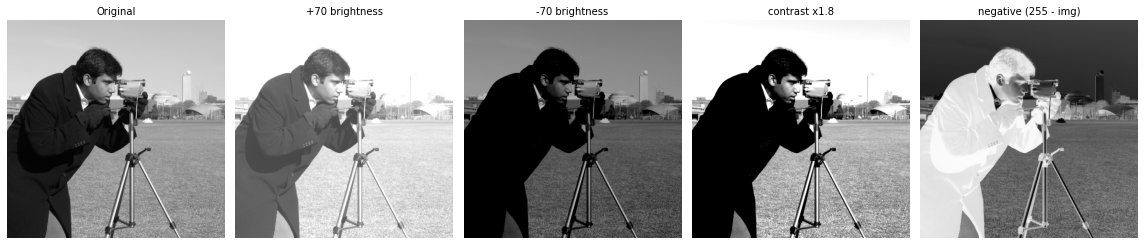


image              min   max     mean
-------------------------------------
original             0   255   129.06
brighter            70   255   192.54
darker               0   185    72.28
contrast             0   255   141.90
negative             0   255   125.94


In [31]:
with np.errstate(over="ignore"):
    print("uint8 overflow demo:", np.uint8(200) + np.uint8(100), "  <- wrapped around!")

brighter = np.clip(img_gray.astype(int) + 70, 0, 255).astype(np.uint8)
darker   = np.clip(img_gray.astype(int) - 70, 0, 255).astype(np.uint8)
contrast = np.clip((img_gray.astype(float) - 128) * 1.8 + 128, 0, 255).astype(np.uint8)
negative = 255 - img_gray

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, image, title in zip(
    axes,
    [img_gray, brighter, darker, contrast, negative],
    ["Original", "+70 brightness", "-70 brightness", "contrast x1.8", "negative (255 - img)"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task5_arithmetic.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"\n{'image':<16}{'min':>6}{'max':>6}{'mean':>9}")
print("-" * 37)
for label, image in [("original", img_gray), ("brighter", brighter),
                     ("darker", darker), ("contrast", contrast),
                     ("negative", negative)]:
    print(f"{label:<16}{image.min():>6}{image.max():>6}{image.mean():>9.2f}")

## 5.4 Boolean masking — thresholding (binarisation)

threshold = 129
pixels above threshold: 167,067 (63.7% of the image)


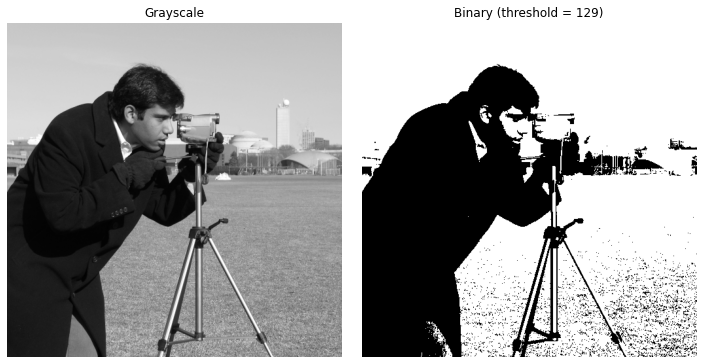

In [32]:
threshold = int(img_gray.mean())
binary = np.where(img_gray > threshold, 255, 0).astype(np.uint8)

print(f"threshold = {threshold}")
print(f"pixels above threshold: {(img_gray > threshold).sum():,} "
      f"({(img_gray > threshold).mean():.1%} of the image)")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_gray, cmap='gray'); axes[0].set_title("Grayscale")
axes[1].imshow(binary,   cmap='gray'); axes[1].set_title(f"Binary (threshold = {threshold})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task5_threshold.png", dpi=100, bbox_inches="tight")
plt.show()

## 5.5 Channel indexing — splitting a colour image

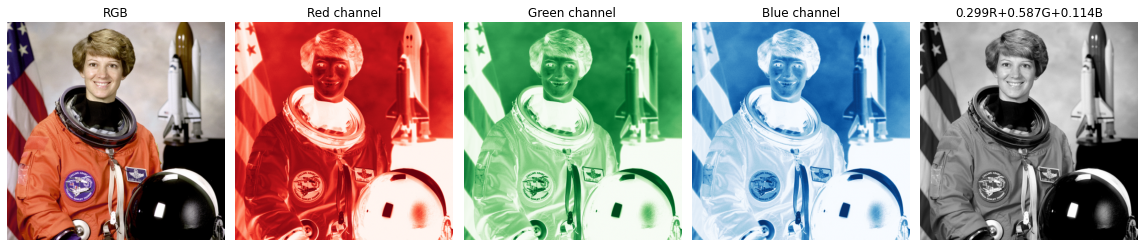

channel       mean   min   max
------------------------------
red         141.56     0   255
green       105.76     0   255
blue         96.48     0   255


In [33]:
red   = color_rgb[:, :, 0]
green = color_rgb[:, :, 1]
blue  = color_rgb[:, :, 2]

gray_manual = (0.299 * red + 0.587 * green + 0.114 * blue).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes[0].imshow(color_rgb);              axes[0].set_title("RGB")
axes[1].imshow(red,   cmap='Reds');     axes[1].set_title("Red channel")
axes[2].imshow(green, cmap='Greens');   axes[2].set_title("Green channel")
axes[3].imshow(blue,  cmap='Blues');    axes[3].set_title("Blue channel")
axes[4].imshow(gray_manual, cmap='gray'); axes[4].set_title("0.299R+0.587G+0.114B")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task5_channels.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"{'channel':<10}{'mean':>8}{'min':>6}{'max':>6}")
print("-" * 30)
for label, channel in [("red", red), ("green", green), ("blue", blue)]:
    print(f"{label:<10}{channel.mean():>8.2f}{channel.min():>6}{channel.max():>6}")

## 5.6 Strided slicing — downsampling, and reshape — quantisation

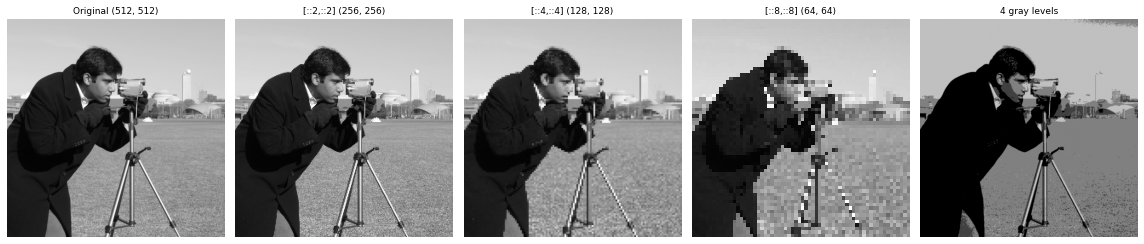

unique gray levels — original : 256
unique gray levels — quantised: 4 -> [  0  64 128 192]


In [34]:
down2 = img_gray[::2, ::2]
down4 = img_gray[::4, ::4]
down8 = img_gray[::8, ::8]

quantised = (img_gray // 64) * 64

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
for ax, image, title in zip(
    axes,
    [img_gray, down2, down4, down8, quantised],
    [f"Original {img_gray.shape}", f"[::2,::2] {down2.shape}",
     f"[::4,::4] {down4.shape}", f"[::8,::8] {down8.shape}",
     "4 gray levels"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=9); ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task5_sampling_quantisation.png", dpi=100, bbox_inches="tight")
plt.show()

print("unique gray levels — original :", len(np.unique(img_gray)))
print("unique gray levels — quantised:", len(np.unique(quantised)),
      "->", np.unique(quantised))

Reducing the *spatial* resolution (downsampling) and reducing the *intensity*
resolution (quantisation) are the two axes along which a digital image is
sampled — the core idea of Outcome #1.

## 5.7 Combining arrays — blending and difference

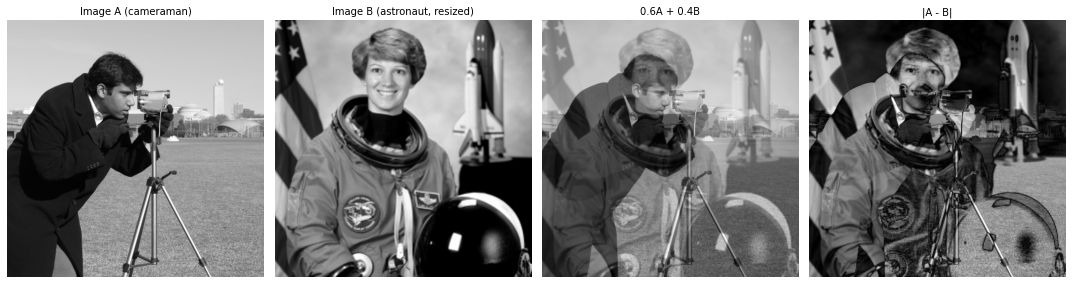

In [35]:
resized = np.array(Image.open('images/astronaut_gray_256.tif').resize((512, 512)))

blend      = (0.6 * img_gray + 0.4 * resized).astype(np.uint8)
difference = np.abs(img_gray.astype(int) - resized.astype(int)).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, image, title in zip(
    axes,
    [img_gray, resized, blend, difference],
    ["Image A (cameraman)", "Image B (astronaut, resized)",
     "0.6A + 0.4B", "|A - B|"],
):
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/task5_blend.png", dpi=100, bbox_inches="tight")
plt.show()

## 5.8 Statistics over an array

In [36]:
print(f"{'statistic':<22}{'cameraman':>12}{'astronaut(gray)':>18}")
print("-" * 52)
stats = [
    ("min",                lambda a: a.min()),
    ("max",                lambda a: a.max()),
    ("mean",               lambda a: a.mean()),
    ("median",             lambda a: np.median(a)),
    ("standard deviation", lambda a: a.std()),
    ("25th percentile",    lambda a: np.percentile(a, 25)),
    ("75th percentile",    lambda a: np.percentile(a, 75)),
]
for label, function in stats:
    print(f"{label:<22}{function(img_gray):>12.2f}{function(img_array):>18.2f}")

print("\nBrightest pixel of cameraman is at (row, col) =",
      tuple(int(v) for v in np.unravel_index(img_gray.argmax(), img_gray.shape)))
print("Darkest   pixel of cameraman is at (row, col) =",
      tuple(int(v) for v in np.unravel_index(img_gray.argmin(), img_gray.shape)))

statistic                cameraman   astronaut(gray)
----------------------------------------------------
min                           0.00              0.00
max                         255.00            254.00
mean                        129.06            112.70
median                      152.00            123.00
standard deviation           73.64             74.37
25th percentile              35.00             39.00
75th percentile             197.00            179.00

Brightest pixel of cameraman is at (row, col) = (120, 426)
Darkest   pixel of cameraman is at (row, col) = (387, 118)


---

# 6 — The scikit-image General-Purpose Image Gallery

Reproduced from
<https://scikit-image.org/docs/stable/auto_examples/data/plot_general.html>.
These are the sample images used throughout this lab; the title above each one
is the name of the `skimage.data` function that returns it.

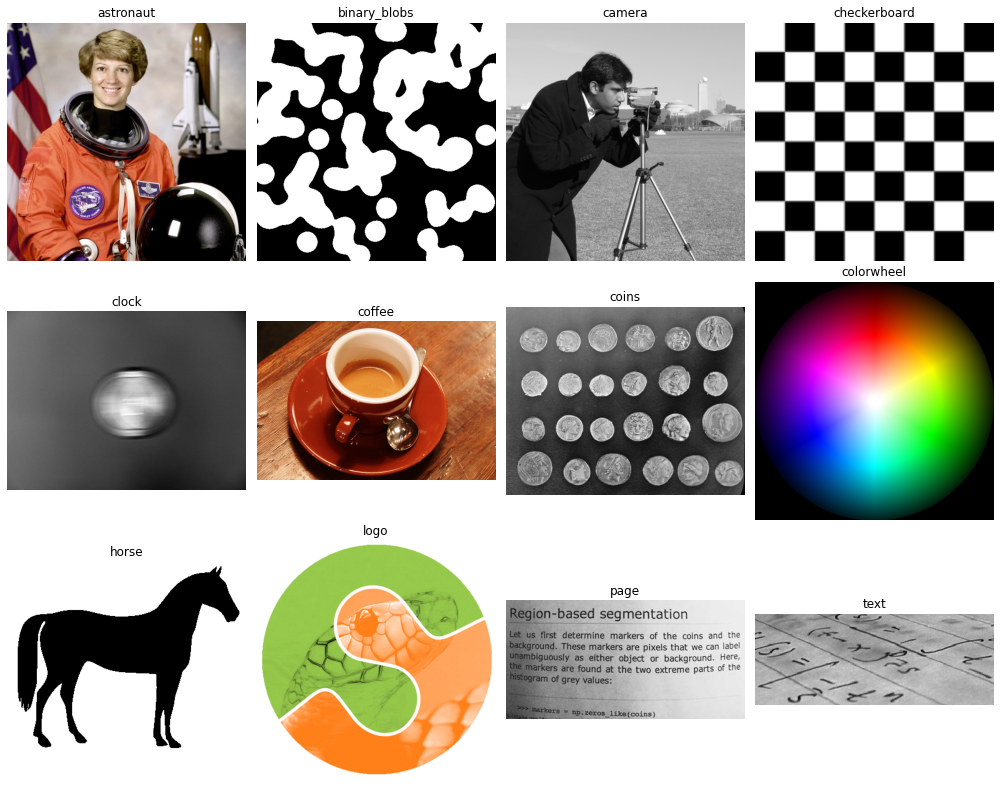

In [37]:
import skimage as ski

gallery = [
    'astronaut', 'binary_blobs', 'camera', 'checkerboard', 'clock',
    'coffee', 'coins', 'colorwheel', 'horse', 'logo', 'page', 'text',
]

fig, axes = plt.subplots(3, 4, figsize=(14, 11))
for ax, name in zip(axes.flat, gallery):
    image = getattr(ski.data, name)()
    if image.ndim == 2:
        ax.imshow(image, cmap=plt.cm.gray)
    else:
        ax.imshow(image)
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/skimage_gallery.png", dpi=100, bbox_inches="tight")
plt.show()

In [38]:
print(f"{'skimage.data function':<22}{'shape':<20}{'dtype':<10}{'kind'}")
print("-" * 64)
for name in gallery:
    image = getattr(ski.data, name)()
    if image.dtype == bool:
        kind = "binary"
    elif image.ndim == 2:
        kind = "grayscale"
    elif image.shape[2] == 4:
        kind = "RGBA"
    else:
        kind = "RGB colour"
    print(f"{name + '()':<22}{str(image.shape):<20}{str(image.dtype):<10}{kind}")

skimage.data function shape               dtype     kind
----------------------------------------------------------------
astronaut()           (512, 512, 3)       uint8     RGB colour
binary_blobs()        (512, 512)          bool      binary
camera()              (512, 512)          uint8     grayscale
checkerboard()        (200, 200)          uint8     grayscale
clock()               (300, 400)          uint8     grayscale
coffee()              (400, 600, 3)       uint8     RGB colour
coins()               (303, 384)          uint8     grayscale
colorwheel()          (370, 371, 3)       uint8     RGB colour
horse()               (328, 400)          bool      binary
logo()                (500, 500, 4)       uint8     RGBA
page()                (191, 384)          uint8     grayscale
text()                (172, 448)          uint8     grayscale


---

# 7 — Files Produced by This Notebook

In [39]:
print("images/ (inputs)")
for f in sorted(os.listdir("images")):
    print(f"   {f:<28}{os.path.getsize('images/' + f) / 1024:>8.1f} KB")

print("\noutputs/ (results)")
for f in sorted(os.listdir("outputs")):
    print(f"   {f:<28}{os.path.getsize('outputs/' + f) / 1024:>8.1f} KB")

images/ (inputs)
   astronaut.png                  414.6 KB
   astronaut_gray_256.tif          64.2 KB
   binary_blobs.png                 7.1 KB
   camera.png                     139.0 KB
   cameraman.tif                  256.2 KB
   checkerboard.png                 0.4 KB
   clock.png                       43.4 KB
   coffee.png                     438.7 KB
   coins.png                       74.0 KB
   colorwheel.png                  81.2 KB
   horse.png                        2.4 KB
   logo.png                       175.5 KB
   logo_rgb.png                   163.3 KB
   page.png                        41.6 KB
   text.png                        41.7 KB

outputs/ (results)
   cameraman_lossless.png         144.9 KB
   cameraman_q10.jpg                7.3 KB
   cameraman_q90.jpg               58.0 KB
   new_image.jpg                   84.6 KB
   new_image2.jpg                  11.7 KB
   skimage_gallery.png           1029.6 KB
   task2_opencv_vs_pil.png        332.6 KB
   task3_compress

---

# 8 — Conclusion

**Outcome #1 — Explain how digital images are represented and manipulated in a
computer.**

What this lab established:

1. **A digital image is a NumPy array of numbers.** A grayscale image is 2-D,
   `(height, width)`; a colour image is 3-D, `(height, width, 3)`. Section 4.3
   showed the same 8 × 8 patch simultaneously as raw integers and as pixels.

2. **`uint8` means 256 gray levels — 8 bits per pixel.** Section 5.3 showed
   what happens when that range is exceeded: 200 + 100 wraps to 44 instead of
   saturating at 255, so arithmetic must cast to a wider type and clip.

3. **Different libraries make different choices.** OpenCV returns arrays in
   **BGR** order and indexes `(height, width)`; PIL returns an `Image` object
   and reports `(width, height)`. Both conventions were demonstrated, along
   with the visual error that follows from confusing them.

4. **File format determines whether pixels survive.** PNG and TIFF round-trip
   with zero error; JPEG at quality 10 introduced visible 8 × 8 block artefacts
   and a large worst-case pixel error.

5. **Array operations are image operations.** Slicing crops, negative strides
   flip, addition changes brightness, `255 - img` inverts, boolean masks
   threshold, strided slicing downsamples, and integer division quantises —
   all with no image-processing library involved. Spatial sampling and
   intensity quantisation, shown in section 5.6, are precisely the two ways a
   continuous scene is turned into a finite array of numbers.

---

<div align="center">

**End of Lab 1**

Nawaf Mohammed Alghamdi — 2240007352
ARTI 403 — Image Processing

</div>